# Numerical Simulation Laboratory - Exercise 7

## INTRODUCTION

In this exercise the Lennard-Jones liquid is studied from **two complementary points of view**: different simulation algorithms and different statistical ensembles. In particular, Monte Carlo is used in the canonical ensemble $(N,V,T)$, while Molecular Dynamics is used in the microcanonical ensemble $(N,V,E)$. In the simulator input, these two cases correspond respectively to `SIMULATION_TYPE = 1` for Lennard-Jones Monte Carlo and `SIMULATION_TYPE = 0` for Lennard-Jones Molecular Dynamics.

In the **canonical ensemble $(N,V,T)$**, the number of particles, the volume and the temperature are fixed, while the energy can fluctuate. In the **microcanonical ensemble $(N,V,E)$**, instead, the number of particles, the volume and the total energy are fixed, while the instantaneous temperature is obtained from the kinetic energy and can fluctuate during the simulation.

- In the **Monte Carlo** approach, the system is sampled through stochastic particle moves. The temperature is imposed as an input parameter, and the **Metropolis** acceptance rule is used to generate configurations distributed according to the Boltzmann weight. This is the same general sampling idea introduced in Laboratory 05 and later reused in other exercises based on the Metropolis algorithm.

- In **Molecular Dynamics**, instead, the system evolves deterministically by integrating Newton's equations of motion. Here the dynamics is performed in the microcanonical ensemble, where the total energy is conserved, and the equations of motion are integrated using the **Verlet** algorithm. This approach was introduced in Laboratory 04.

The particles interact through the Lennard-Jones potential,

$$
V_{\mathrm{LJ}}(r) = 4\epsilon \left[
\left(\frac{\sigma}{r}\right)^{12}
-
\left(\frac{\sigma}{r}\right)^6
\right],
$$

which contains a short-range repulsive part, proportional to $r^{-12}$, and a longer-range attractive part, proportional to $r^{-6}$. In reduced Lennard-Jones units, energies are measured in units of $\epsilon$ and lengths in units of $\sigma$.

In practical simulations the interaction is truncated at a finite cut-off radius. This makes the computation more efficient, but it also neglects the residual long-range contribution of the potential. **Tail corrections** are therefore introduced to estimate analytically the missing contribution to the potential energy and to the pressure.

The **radial distribution function $g(r)$** is used to describe how particles are arranged in the liquid. Differently from $U/N$ and $P$, which are single average quantities, $g(r)$ gives spatial information about the system.
In particular, it shows whether particles are more or less likely to be found at a distance $r$ from a reference particle. Peaks in $g(r)$ correspond to typical distances between neighbouring particles, while the small values at very short distances are due to the repulsive core of the Lennard-Jones potential.

The aim of this exercise is therefore to compare two descriptions of the same physical system: a canonical stochastic sampling and a microcanonical deterministic dynamics. Although the two simulations generate configurations in different ways, they should give compatible equilibrium estimates for observables such as $U/N$, $P$ and $g(r)$, provided that the systems are properly equilibrated.

The simulation is performed in reduced Lennard-Jones units. The liquid phase considered here has $\rho^\star=0.8$, target temperature $T^\star=1.1$, and cut-off radius $r_c^\star=2.5$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

plt.rcParams["figure.dpi"] = 100

def read_block_file(filepath):
    return pd.read_csv(
        filepath,
        sep=r"\s+",
        comment="#",
        header=None,
        names=["block", "actual", "average", "error"]
    )

## EXERCISE 07.1

### Assignment prompt

In the NSL simulator code we have provided, include tail corrections for potential energy, $U$, and pressure $P$.

### Method

Because periodic boundary conditions are used, the simulation box is repeated periodically in space. Therefore, when computing the distance between two particles, the code considers the closest periodic image of the particles.

The Lennard-Jones potential is then truncated at the cut-off radius $r_c$: only particle pairs closer than $r_c$ contribute explicitly to the energy and pressure.

As a consequence, the simulation neglects the residual interaction between particles separated by distances larger than $r_c$. Tail corrections provide an analytical estimate of this missing long-range contribution.

The approximation used is that, beyond the cut-off radius, the fluid has no significant spatial correlations. In other words, the particles can be considered almost uniformly distributed, so the probability of finding another particle is approximately the same as in an ideal gas. This corresponds to assuming

$$
g(r) \simeq 1 \qquad \text{for } r>r_c .
$$

For the potential energy per particle the correction is

$$
\frac{U_{\mathrm{tail}}}{N} = \frac{8\pi\rho}{3}\left(\frac{1}{3r_c^9}-\frac{1}{r_c^3}\right),
$$

while for the pressure the corresponding correction is

$$
P_{\mathrm{tail}} = 32\pi\rho^2\left(\frac{1}{9r_c^9}-\frac{1}{6r_c^3}\right).
$$

### C++ implementation

From `system.cpp`

```cpp
_vtail = (8.0/3.0)*((M_PI*_rho/(3*pow(_r_cut,9)))
                    - (M_PI*_rho/pow(_r_cut,3)));

_ptail = 32.0 * M_PI * _rho * (1.0 / (9.0 * pow(_r_cut, 9))
                               - 1.0 / (6.0 * pow(_r_cut, 3)));
```

The variables `_vtail` and `_ptail` store the analytical tail corrections used in the measurement of potential energy and pressure.

The correction to the **potential energy** is straightforward: `_vtail` is already the tail correction per particle, so it is added directly to the measured value of $U/N$:

```cpp
penergy_temp = _vtail + 4.0 * penergy_temp / double(_npart);
```

The **pressure** estimator has three contributions:

$$
P = P_{\mathrm{ideal}} + P_{\mathrm{virial}} + P_{\mathrm{tail}} .
$$

In the code this is written as

```cpp
_measurement[_index_pressure] = _rho * (2.0/3.0) * kenergy_temp + (_ptail*_npart + 48.0*virial/3.0)/_volume;
```

The first term,

```cpp
_rho * (2.0/3.0) * kenergy_temp
```

is the ideal-gas contribution to the pressure.

The term containing `virial` is the contribution of the Lennard-Jones forces that are explicitly computed in the pair loop, for particle pairs with distance smaller than the cut-off radius:

```cpp
48.0*virial/(3.0*_volume)
```

The term containing `_ptail` is the analytical correction for the part of the interaction neglected beyond the cut-off:

```cpp
_ptail*_npart/_volume
```

Since

$$
\frac{N}{V}=\rho ,
$$

this last term is equal to `_ptail` multiplied by another factor of density. This is why `_ptail` contains only one explicit factor of $\rho$ in its definition, while the final pressure tail correction $P_{\mathrm{tail}}$ is proportional to $\rho^2$.

These corrections are deterministic terms computed from $\rho$ and $r_c$: they are not sampled as additional observables, but are added to the measured potential energy and pressure to account for the interaction neglected beyond the cut-off radius.

## EXERCISE 07.2

### Assignment prompt

Use the NSL simulator code to print out **instantaneous** values of potential energy per particle, $U/N$, along **equilibrated** Monte Carlo $(N,V,T)$ and Molecular Dynamics $(N,V,E)$ simulations of $M=5\times 10^5$ MC steps or MD time steps (where, for MC, the Metropolis acceptance ratio should be fixed approximately to 50% by changing the value of $dt$ that, in the MC case, represent the amplitude of the step in each direction) in the following thermodynamic conditions:
- liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r^\star_c = 2.5$, for MD $dt^\star=0.001$)

Equilibration is needed both with MC and with MD. With MD, you will observe that starting from a perfect crystalline configuration the temperature, $T$, will not conserve its value. Explore and find the starting value of $T$ needed to stabilize, after a certain number of time steps (equilibration time), the average value of $T$ on the desired $T^\star$.
Perform your MC and MD simulations by re-starting after such equilibration time.

1. Once this data has been produced, compute and make pictures with a python script of the autocorrelation functions of $U/N$ to approximately estimate how large the blocks in your simulations should be.
2. Use the same data to study, with a python script, the estimation of the statistical uncertainties of the expectation value of $U/N$ for different size of the blocks in the data blocking technique, from $L=M/N=10$ to $L=5\times 10^3$, being $N$ the number of blocks. Make pictures of these statistical uncertainties as a function of $L$. What you observe in the statistical uncertainties after that the block size is large enough (from the point of view of the data blocking technique)?

### Method

The purpose of this part is to generate instantaneous values of the potential energy per particle, $U/N$, for both MC NVT and MD NVE simulations. These time series are later used to compute the autocorrelation function and to study the dependence of the statistical uncertainty on the block size.

For the Monte Carlo simulation, the input structure used for the instantaneous production run is

```text
SIMULATION_TYPE        1
RESTART                1
TEMP                   1.1
NPART                  108
RHO                    0.8
R_CUT                  2.5
DELTA                  0.1
NBLOCKS                500000
NSTEPS                 1
```

Here `SIMULATION_TYPE = 1` selects the Lennard-Jones Monte Carlo simulation. The temperature is fixed to the target value $T^\star=1.1$, while `DELTA = 0.1` is the maximum displacement amplitude for the trial moves. This value gives an acceptance rate close to the requested value of $50\%$.

For the Molecular Dynamics simulation, the corresponding input structure is

```text
SIMULATION_TYPE        0
RESTART                1
TEMP                   T_input
NPART                  108
RHO                    0.8
R_CUT                  2.5
DELTA                  0.001
NBLOCKS                500000
NSTEPS                 1
```

The parameter `DELTA` has a different meaning in the two simulations. In MC, `DELTA = 0.1` is the maximum displacement amplitude of the random trial move and was tuned to obtain an acceptance rate close to $50\%$. In MD, `DELTA = 0.001` is the Verlet integration time step, fixed by the assignment.

Here `SIMULATION_TYPE = 0` selects the Lennard-Jones Molecular Dynamics simulation, and `DELTA = 0.001` is the integration time step. The parameter `TEMP` is the starting temperature used to initialize the velocities. Since the MD simulation is microcanonical, this starting value does not necessarily coincide with the equilibrated kinetic temperature.

In both cases,

```text
NBLOCKS                500000
NSTEPS                 1
```

is used as a practical way to write one instantaneous value at each MC step or MD time step. Therefore, the total number of recorded values is

$$
M = 5\times 10^5.
$$

For the instantaneous time series used in the autocorrelation and block-size analyses, the only strictly required observable in `properties.dat` is

```text
POTENTIAL_ENERGY
```

The first plots below are used to check the equilibration behaviour of the simulations. In particular, an initial MD run started from the nominal target temperature $T^\star=1.1$ is shown to motivate the subsequent scan of the MD starting temperature.

### C++ implementation

For `SIMULATION_TYPE = 1`, the simulator performs a Lennard-Jones Monte Carlo move. A particle is selected and displaced by a random vector whose components are uniformly sampled in the interval $[-\delta,\delta]$, where $\delta$ is the value of `DELTA` in `input.dat`.

From `system.cpp`:

```cpp
if(_sim_type == 1){       // LJ system
  vec shift(_ndim);       // Will store the proposed translation

  for(int j=0; j<_ndim; j++){
    shift(j) = _rnd.Rannyu(-1.0,1.0) * _delta;
  }

  _particle(i).translate(shift, _side);

  if(this->metro(i)){     // Metropolis acceptance evaluation
    _particle(i).acceptmove();
    _naccepted++;
  } else {
    _particle(i).moveback();
  }
}
```

The parameter `DELTA = 0.1` therefore controls the maximum amplitude of the random displacement proposed in each Cartesian direction. This is different from the MD case, where `DELTA = 0.001` is the Verlet time step.

The proposed move is accepted or rejected by the Metropolis rule. The energy difference is computed from the Lennard-Jones interaction of the moved particle with all the other particles:

```cpp
if(_sim_type == 1)
  delta_E = this->Boltzmann(i,true) - this->Boltzmann(i,false);

acceptance = exp(-_beta*delta_E);

if(_rnd.Rannyu() < acceptance)
  decision = true;
```

Here `_beta = 1/T` is fixed by the canonical temperature. The function `Boltzmann()` evaluates the local Lennard-Jones energy of particle `i`, either in the proposed position (`xnew = true`) or in the old position (`xnew = false`):

```cpp
double System :: Boltzmann(int i, bool xnew){
  double energy_i = 0.0;
  double dx, dy, dz, dr;

  for(int j=0; j<_npart; j++){
    if(j != i){
      dx = this->pbc(_particle(i).getposition(0,xnew)
                     - _particle(j).getposition(0,1), 0);
      dy = this->pbc(_particle(i).getposition(1,xnew)
                     - _particle(j).getposition(1,1), 1);
      dz = this->pbc(_particle(i).getposition(2,xnew)
                     - _particle(j).getposition(2,1), 2);

      dr = sqrt(dx*dx + dy*dy + dz*dz);

      if(dr < _r_cut){
        energy_i += 1.0/pow(dr,12) - 1.0/pow(dr,6);
      }
    }
  }

  return 4.0 * energy_i;
}
```

The periodic boundary conditions are applied through `pbc()`, and only pairs with distance smaller than the cut-off radius contribute to the energy. The returned value is the Lennard-Jones interaction energy of the selected particle with the rest of the system. Therefore, the difference between the two calls to `Boltzmann()` gives the energy variation associated with the proposed displacement.

The value of `DELTA` is tuned so that the acceptance rate is close to $50\%$, as requested by the assignment.

### Instantaneous values

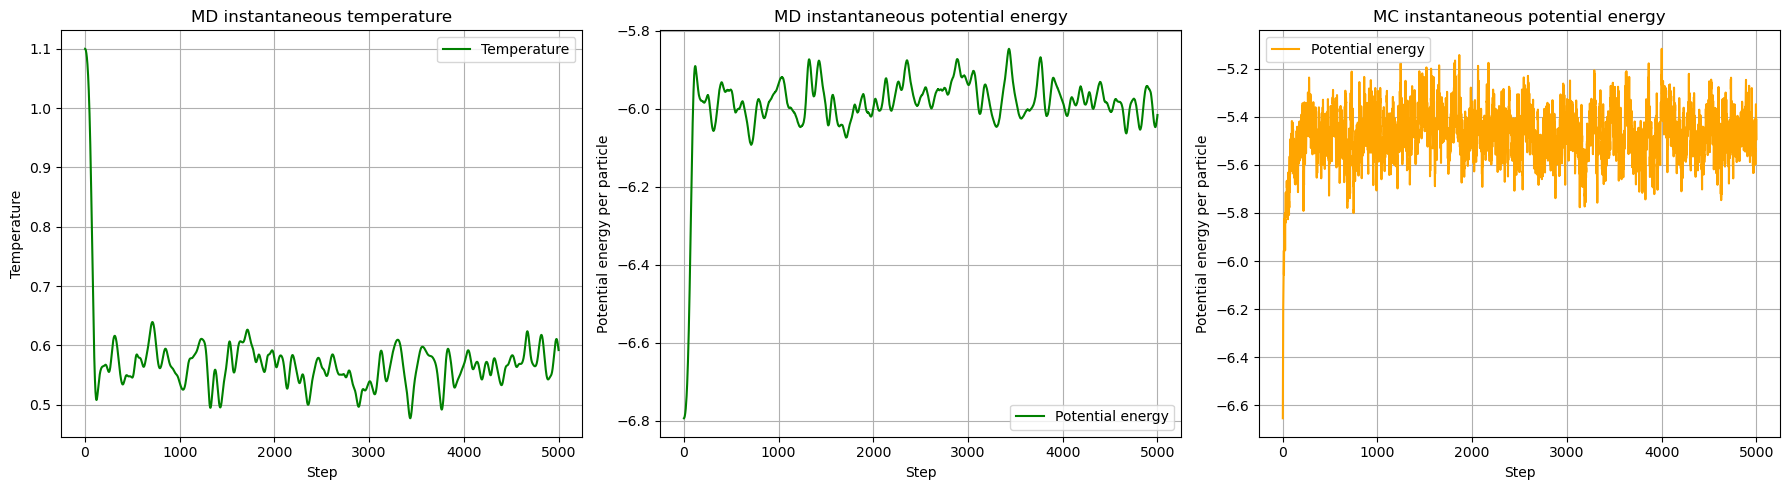

In [2]:
# =========================
# Equilibration: temperature MD
# =========================
temp_path = Path("Nsl_simulator_Ex_07_2/EQUILIBRAZIONE/Equilibration_MD/temperature.dat")
temperature = read_block_file(temp_path)

# =================================
# Equilibration: potential energy MD
# =================================
peq_path = Path("Nsl_simulator_Ex_07_2/EQUILIBRAZIONE/Equilibration_MD/potential_energy.dat")
potential_energy_eq = read_block_file(peq_path)

# =================================
# Equilibration: potential energy MC
# =================================
pprod_path = Path("Nsl_simulator_Ex_07_2/EQUILIBRAZIONE/Equilibration_MC/potential_energy.dat")
potential_energy_prod = read_block_file(pprod_path)

x_temp = np.arange(1, len(temperature) + 1)
x_pe_eq = np.arange(1, len(potential_energy_eq) + 1)
x_pe_prod = np.arange(1, len(potential_energy_prod) + 1)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(x_temp, temperature["actual"], label="Temperature", color="green")
axs[0].set_title("MD instantaneous temperature")
axs[0].set_xlabel("Step")
axs[0].set_ylabel("Temperature")
axs[0].grid(True)
axs[0].legend()

axs[1].plot(x_pe_eq, potential_energy_eq["actual"], label="Potential energy", color="green")
axs[1].set_title("MD instantaneous potential energy")
axs[1].set_xlabel("Step")
axs[1].set_ylabel("Potential energy per particle")
axs[1].grid(True)
axs[1].legend()

axs[2].plot(x_pe_prod, potential_energy_prod["actual"], label="Potential energy", color="orange")
axs[2].set_title("MC instantaneous potential energy")
axs[2].set_xlabel("Step")
axs[2].set_ylabel("Potential energy per particle")
axs[2].grid(True)
axs[2].legend()

plt.tight_layout()
plt.show()

#### Comment

The first plot shows that, when the MD simulation is initialized at the nominal target temperature $T^\star=1.1$, the kinetic temperature moves away from that value during equilibration.

For this reason, the MD simulation cannot simply be started from $T^\star=1.1$ and expected to be directly comparable with the MC simulation. In MC, the temperature used in the Metropolis probability is fixed at the target value, while in MD the equilibrated kinetic temperature can be different from the initial input temperature. Therefore, a scan over the MD starting input temperature is needed in order to obtain an equilibrated MD temperature close to the MC target temperature.

In the MC simulation, after the initial equilibration of the Markov chain, the potential energy fluctuates around the equilibrium value corresponding to the target canonical temperature.

### Equilibration strategy

Before producing the final data, a preliminary equilibration study was performed for both simulations.

For the MC simulation, the temperature is fixed directly by the canonical ensemble at $T^\star=1.1$. The only parameter that needed to be tuned was the displacement amplitude of the trial moves. The value $\delta=0.1$ was chosen because it gives an acceptance rate close to the requested value of $50\%$.

For the MD simulation, the situation is different. Since the dynamics is microcanonical, the input temperature only fixes the initial velocities. Starting from an ordered configuration, part of the initial kinetic energy is converted into potential energy during equilibration, so the measured kinetic temperature after equilibration is not equal to the input temperature.

For this reason, several preliminary MD runs were performed with different starting temperatures. In these runs, the input file had the same physical parameters as the final simulation, while the value of `TEMP` was varied:

```text
SIMULATION_TYPE        0
RESTART                0
TEMP                   1.90 ... 2.10
NPART                  108
RHO                    0.8
R_CUT                  2.5
DELTA                  0.001
NBLOCKS                5000
NSTEPS                 1
```

During these preliminary runs, the equilibrated kinetic temperature was monitored. The value $T_{\mathrm{input}}=1.98$ was chosen because, after equilibration, it gives an average kinetic temperature close to the target value $T^\star=1.1$.

This value of the input temperature was then used to prepare the final microcanonical state. The final MD production run can therefore be compared with the MC simulation at the same target liquid state, characterized by $\rho^\star=0.8$ and an equilibrated temperature close to $T^\star=1.1$.

### MD input temperature scan

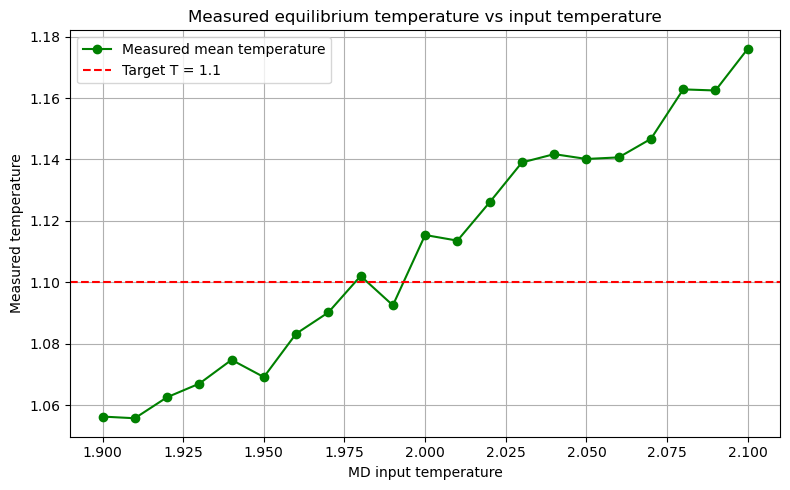

In [3]:
base_path = Path("Nsl_simulator_Ex_07_2/ANALISI_TEMPERATURA")

temps = []
mean_temps = []

for folder in sorted(base_path.glob("TEMP_*")):
    T = float(folder.name.split("_")[1])
    data = read_block_file(folder / "temperature.dat")
    mean_T = data["actual"].mean()

    temps.append(T)
    mean_temps.append(mean_T)

temps = np.array(temps)
mean_temps = np.array(mean_temps)
idx = np.argsort(temps)
temps = temps[idx]
mean_temps = mean_temps[idx]

plt.figure(figsize=(8, 5))
plt.plot(temps, mean_temps, "o-", label="Measured mean temperature", color="green")
plt.axhline(1.1, linestyle="--", color="red", label="Target T = 1.1")
plt.xlabel("MD input temperature")
plt.ylabel("Measured temperature")
plt.title("Measured equilibrium temperature vs input temperature")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Comment

From the scan, an MD input temperature of about $T_{\mathrm{input}}=1.98$ gives an average measured temperature very close to the desired value $T^\star=1.1$. The production MD run was therefore performed using this input value, after the equilibration stage, so that the final NVE simulation is comparable with the MC NVT simulation at the same thermodynamic conditions.

### Autocorrelation analysis

The autocorrelation function of the instantaneous potential energy per particle is computed as

$$
C(k)=\frac{\langle (U_i-\langle U\rangle)(U_{i+k}-\langle U\rangle)\rangle}
{\langle (U_i-\langle U\rangle)^2\rangle}.
$$

It measures how many simulation steps are needed before two measurements of $U/N$ can be treated as approximately independent. This information is used to choose a block length much larger than the correlation scale, so that the block averages provide a reliable estimate of the statistical uncertainty.

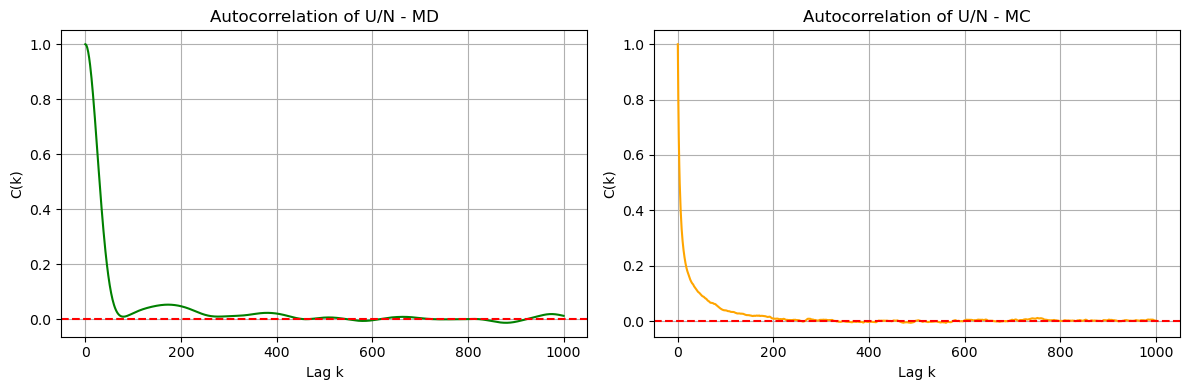

In [4]:
def autocorrelation(x, max_lag):
    x = np.asarray(x, dtype=float)

    # Subtract the mean value
    x = x - np.mean(x)
    n = len(x)

    acf = []

    for lag in range(max_lag + 1):
        # Products between values separated by 'lag'
        values = x[:n-lag] * x[lag:]

        # Average correlation at this lag
        c_lag = np.mean(values)
        acf.append(c_lag)

    acf = np.array(acf)

    # Normalize so that C(0) = 1
    acf = acf / acf[0]

    return acf

max_lag = 1000
lags = np.arange(max_lag + 1)

file_md = Path("Nsl_simulator_Ex_07_2/DATI_MD/potential_energy.dat")
data_md = read_block_file(file_md)
u_md = data_md["actual"].to_numpy()
acf_md = autocorrelation(u_md, max_lag)

file_mc = Path("Nsl_simulator_Ex_07_2/DATI_MC/potential_energy.dat")
data_mc = read_block_file(file_mc)
u_mc = data_mc["actual"].to_numpy()
acf_mc = autocorrelation(u_mc, max_lag)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(lags, acf_md, linewidth=1.5, color="green")
axes[0].axhline(0.0, linestyle="--", color="red")
axes[0].set_ylabel("C(k)")
axes[0].set_xlabel("Lag k")
axes[0].set_title("Autocorrelation of U/N - MD")
axes[0].grid(True)

axes[1].plot(lags, acf_mc, linewidth=1.5, color="orange")
axes[1].axhline(0.0, linestyle="--", color="red")
axes[1].set_xlabel("Lag k")
axes[1].set_ylabel("C(k)")
axes[1].set_title("Autocorrelation of U/N - MC")
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### Comment

The autocorrelation decreases on a scale of a few hundred steps or less for both dynamics. The MC data decorrelate more slowly, while the MD autocorrelation shows a faster initial decay. In both cases, however, the correlation is already small well before $L=1000$ steps. Choosing blocks of length $L=5000$ is therefore a conservative choice, because each block is much longer than the relevant correlation scale.

### Supplementary check: MC acceptance rate

This check is not required by the assignment. It was added because, in a first version of the code, the acceptance rate showed a slowly decreasing trend. At first sight, this could have suggested that the MC simulation was not yet equilibrated, even after the number of steps suggested by the autocorrelation analysis.

The reason was instead technical. The acceptance counters were not reset between blocks, so the value written to file was not the acceptance rate of the single block, but a cumulative acceptance rate from the beginning of the simulation:

```cpp
void System :: block_reset(int blk){
  ...
  _block_av.zeros();

  // _naccepted = 0;
  // _nattempts = 0;
}
```

and the acceptance was written as

```cpp
fraction = double(_naccepted)/double(_nattempts);
```

In this form, the curve is a running average. Therefore it changes very smoothly and can show an apparent decreasing trend if the acceptance measured during the first part of the run is higher than the later equilibrium value. This does not necessarily mean that the system is still equilibrating.

To check this point, the code was modified by resetting the acceptance counters at the end of each block:

```cpp
void System :: block_reset(int blk){
  ...
  _block_av.zeros();

  _naccepted = 0;
  _nattempts = 0;
}
```

With this modification, each point in the acceptance plot represents the acceptance rate measured only within that block. The resulting curve fluctuates around an approximately constant value close to the target acceptance of $0.5$. This confirms that the previous decreasing trend was a consequence of the cumulative definition of the acceptance rate, not a sign of poor equilibration.

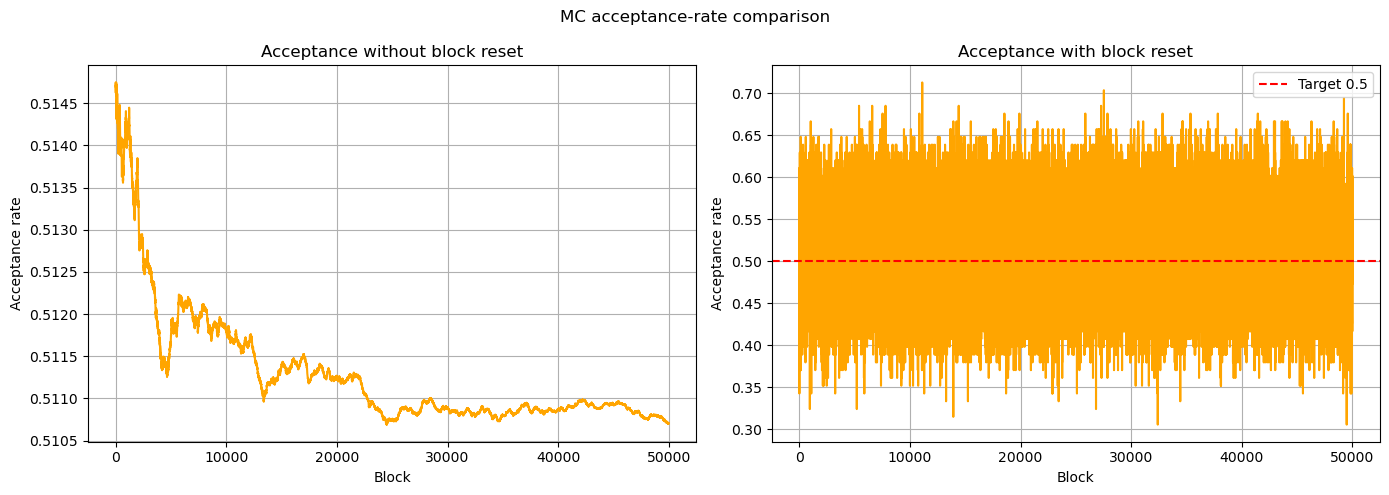

In [5]:
file_path1 = Path("Nsl_simulator_Ex_07_2/ACCEPTANCE/Without_reset/acceptance.dat")
file_path2 = Path("Nsl_simulator_Ex_07_2/ACCEPTANCE/With_reset/acceptance.dat")

data1 = pd.read_csv(file_path1, sep=r"\s+", comment="#", header=None, names=["block", "acceptance"])
data2 = pd.read_csv(file_path2, sep=r"\s+", comment="#", header=None, names=["block", "acceptance"])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(data1["block"], data1["acceptance"], linewidth=1.5, color="orange")
axes[0].set_xlabel("Block")
axes[0].set_ylabel("Acceptance rate")
axes[0].set_title("Acceptance without block reset")
axes[0].grid(True)

axes[1].plot(data2["block"], data2["acceptance"], linewidth=1.5, color="orange")
axes[1].axhline(0.5, linestyle="--", color="red", label="Target 0.5")
axes[1].set_xlabel("Block")
axes[1].set_ylabel("Acceptance rate")
axes[1].set_title("Acceptance with block reset")
axes[1].grid(True)
axes[1].legend()

plt.suptitle("MC acceptance-rate comparison")
plt.tight_layout()
plt.show()

### What you observe in the statistical uncertainties after that the block size is large enough (from the point of view of the data blocking technique)?

For each **block size $L$**, the $M=5\times10^5$ instantaneous values are divided into $N=M/L$ blocks. The average of each block is computed first, and the statistical uncertainty is then estimated from the variance of the block averages.

In [6]:
def data_blocking_error(data, L):
    N = len(data) // L

    if N <= 1:
        return np.nan

    data_truncated = data[:N*L]
    blocks = data_truncated.reshape(N, L)
    block_means = np.mean(blocks, axis=1)

    global_mean = np.mean(block_means)
    global_mean_squared = np.mean(block_means**2)

    error = np.sqrt((global_mean_squared - global_mean**2) / (N - 1))
    return error

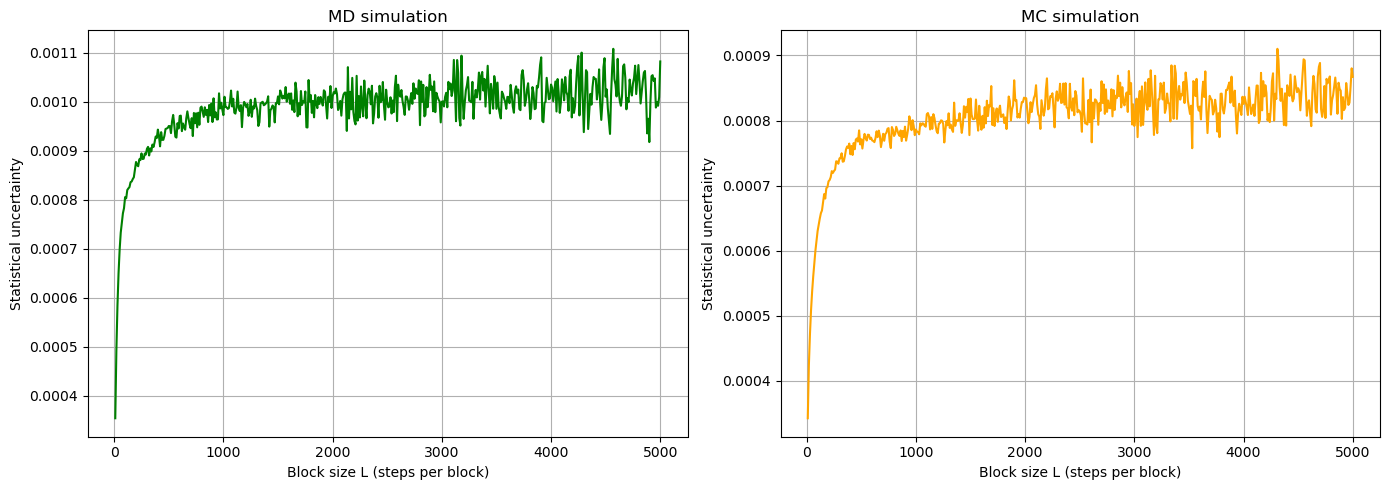

In [7]:
single_values_md = data_md["actual"].values
single_values_mc = data_mc["actual"].values

errors_md = []
errors_mc = []

L_range = np.arange(10, 5000 + 10, 10).astype(int)

for L in L_range:
    errors_md.append(data_blocking_error(single_values_md, L))
    errors_mc.append(data_blocking_error(single_values_mc, L))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(L_range, errors_md, color="green")
axes[0].set_xlabel("Block size L (steps per block)")
axes[0].set_ylabel("Statistical uncertainty")
axes[0].set_title("MD simulation")
axes[0].grid(True)

axes[1].plot(L_range, errors_mc, color="orange")
axes[1].set_xlabel("Block size L (steps per block)")
axes[1].set_ylabel("Statistical uncertainty")
axes[1].set_title("MC simulation")
axes[1].grid(True)

plt.tight_layout()
plt.show()

#### Comment

For small $L$, the block size is too short and the statistical uncertainty is still underestimated. As $L$ increases, the estimated error increases and then becomes approximately stable.

This stability indicates that the blocks are long enough to give a reliable uncertainty estimate. For this reason, a block size of $L=5\times10^3$ is a safe choice for the final production averages.

## EXERCISE 07.3

### Assignment prompt

Include the calculation of the radial distribution function, $g(r)$, as a function of the radial distance $r$ among particles, with $r \in \left[ 0; L/2\right]$ inside the NSL simulator code: average value of $g(r)$ in each block, final average value of $g(r)$ with statistical uncertainties in a separate file.

### Method

The radial distribution function $g(r)$ measures how the particle density changes as a function of the distance from a reference particle. More precisely, $\rho g(r)\Delta V$ is the average number of particles expected in a spherical shell of volume $\Delta V$ at distance $r$ from a given particle.

For an ideal gas, particles are uniformly distributed and $g(r)\simeq 1$. In an interacting liquid, instead, $g(r)$ contains information about the local structure of the fluid: it is small at very short distances because of the repulsive core of the Lennard-Jones potential, and it shows peaks corresponding to the typical distances between neighbouring particles.

In the simulation, distances are computed using periodic boundary conditions, considering the closest periodic image of the particles. The interval

$$
[0,L_{\mathrm{box}}/2]
$$

is divided into radial bins. The upper limit $L_{\mathrm{box}}/2$ is used because, with periodic boundary conditions, distances larger than half the box side are not independent when the closest periodic image is used.

For a spherical shell between $r_{\mathrm{lower}}$ and $r_{\mathrm{upper}}$, the normalization volume is

$$
\Delta V =
\frac{4\pi}{3}
\left(
r_{\mathrm{upper}}^3-r_{\mathrm{lower}}^3
\right).
$$

Each particle pair is assigned to the radial bin corresponding to its distance.

### C++ implementation

The radial distribution function is computed from the particle positions. The relevant part of the implementation is inside the pair loop in `measure()`. For each unordered pair of particles, the code first computes the distance `dr` using periodic boundary conditions:

```cpp
for(int i=0; i<_npart-1; i++){
  for(int j=i+1; j<_npart; j++){

    dx = this->pbc(_particle(i).getposition(0,1)
                   - _particle(j).getposition(0,1), 0);
    dy = this->pbc(_particle(i).getposition(1,1)
                   - _particle(j).getposition(1,1), 1);
    dz = this->pbc(_particle(i).getposition(2,1)
                   - _particle(j).getposition(2,1), 2);

    dr = sqrt(dx*dx + dy*dy + dz*dz);
  }
}
```

The distance `dr` is then assigned to the corresponding radial bin:

```cpp
if(_measure_gofr){
  for(int k=1; k<_n_bins_g+1; k++){
    if(dr >= (k-1)*_bin_size_g && dr < k*_bin_size_g){
      double r_lower = (k-1) * _bin_size_g;
      double r_upper = k * _bin_size_g;
      double delta_v = (4.0/3.0) * M_PI
                       * (pow(r_upper,3) - pow(r_lower,3));

      _measurement(_index_gofr + k - 1) += 2.0 / (delta_v * _npart * _rho);
      break;
    }
  }
}
```

The variable `delta_v` is the volume $\Delta V$ of the spherical shell associated with that radial bin.

The division by $\Delta V$ is needed because bins at larger distances correspond to larger shell volumes. Even in a uniform system, more particles would be found at larger $r$ simply because the available volume is larger. Dividing by $\Delta V$ removes this geometrical effect.

The factor $\rho\,\Delta V$ represents the average number of particles expected in that shell around one reference particle for a uniform fluid with density $\rho$. Multiplying by $N$ gives the expected number of contributions when each particle is considered as a reference particle.

In the code, the loop runs over unordered pairs, with `j > i`. Therefore each pair is counted only once. Since the same pair contributes to the environment of both particles, a factor of $2$ is included:

$$
\text{increment} =
\frac{2}{N\,\rho\,\Delta V}.
$$

With this normalization, a uniform ideal gas would give $g(r)\simeq 1$, while deviations from $1$ describe the local structure of the liquid.

### Comment

At the end of each block, the code writes the block estimate, the progressive average and the statistical uncertainty for every radial bin in `gofr.dat`.

This implementation therefore produces $g(r)$ with the same data-blocking structure used for the other observables. In the plots below, the value shown for each radial bin is the last progressive average, while the uncertainty is the corresponding final statistical error.

## EXERCISE 07.4

### Assignment prompt

By means of your upgraded NSL simulator code, equilibrate and perform MC NVT and MD NVE simulations via a Lennard-Jones model of Argon ($\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) in the following conditions:
- liquid phase: $\rho^\star = 0.8$, $T^\star = 1.1$ (cut-off radius: $r_c = 2.5$)

show in pictures the obtained average values and uncertainties for the potential energy per particle, $U/N$, the pressure $P$ and the radial distribution function $g(r)$ in LJ units ...  and compare your MC results for these quantities with those obtained via MD NVE simulations in similar thermodynamic conditions.

### Method

The final production simulations are performed for the liquid phase at $\rho^\star=0.8$ and target temperature $T^\star=1.1$. All quantities are reported in reduced Lennard-Jones units.

In the MC simulation, the temperature is fixed directly in the canonical sampling. The production input is

```text
SIMULATION_TYPE        1
RESTART                1
TEMP                   1.1
NPART                  108
RHO                    0.8
R_CUT                  2.5
DELTA                  0.1
NBLOCKS                100
NSTEPS                 5000
```

In the MD simulation, instead, the trajectory is microcanonical: the input temperature is used only to prepare the initial velocities, while the final equilibrium state is selected through the total energy. The production input is

```text
SIMULATION_TYPE        0
RESTART                1
TEMP                   1.98
NPART                  108
RHO                    0.8
R_CUT                  2.5
DELTA                  0.001
NBLOCKS                100
NSTEPS                 5000
```

The MD production run is therefore the one prepared with the input temperature $T_{\mathrm{input}}=1.98$, chosen in the equilibration study, so that the equilibrated kinetic temperature is close to $T^\star=1.1$.

The final averages are obtained with data blocking, using $N=100$ blocks of $L=5\times10^3$ steps. This block size was chosen from the autocorrelation and block-size analyses performed in Exercise 07.2.

The quantities compared between MC NVT and MD NVE are the potential energy per particle $U/N$, the pressure $P$, and the radial distribution function $g(r)$. The reported values of $U/N$ and $P$ include the tail corrections discussed in Exercise 07.1.

### Radial distribution function

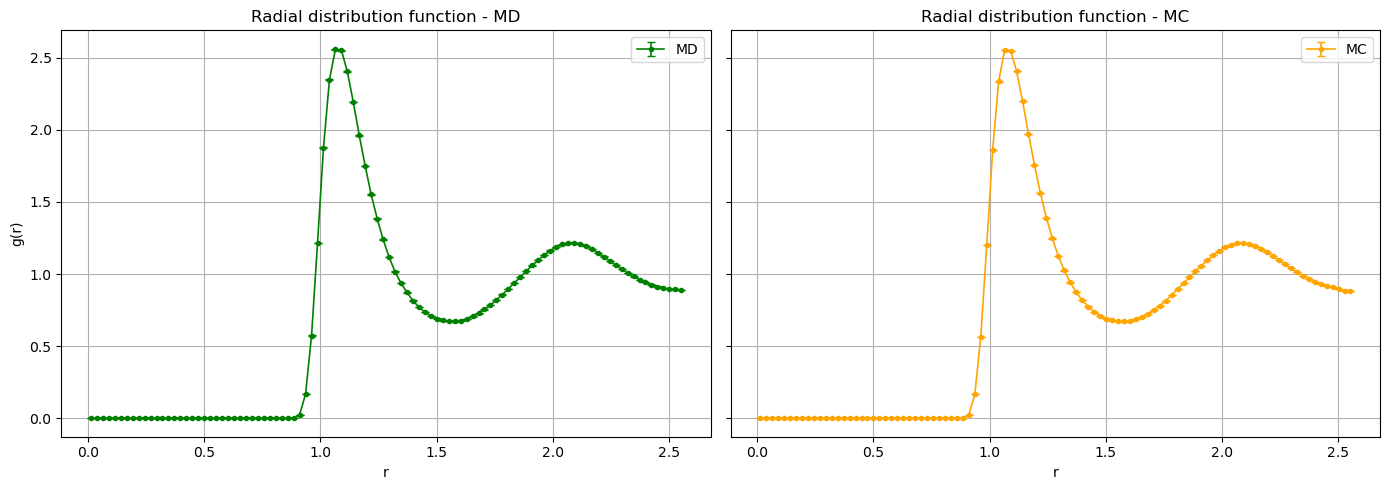

In [8]:
def load_last_block_gofr(filepath):
    data = pd.read_csv(filepath, sep=r"\s+")
    data.columns = ["BLOCK", "DISTANCE", "ACTUAL_GOFR", "AVE_GOFR", "ERROR"]

    last_block = data["BLOCK"].max()
    last_data = data[data["BLOCK"] == last_block].copy()
    return last_data

md_gofr = load_last_block_gofr("Nsl_simulator_Ex_07_4/MD/gofr.dat")
mc_gofr = load_last_block_gofr("Nsl_simulator_Ex_07_4/MC/gofr.dat")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].errorbar(
    md_gofr["DISTANCE"],
    md_gofr["AVE_GOFR"],
    yerr=md_gofr["ERROR"],
    fmt="-o",
    markersize=3,
    linewidth=1.2,
    capsize=3,
    label="MD",
    color="green"
)
axes[0].set_xlabel("r")
axes[0].set_ylabel("g(r)")
axes[0].set_title("Radial distribution function - MD")
axes[0].grid(True)
axes[0].legend()

axes[1].errorbar(
    mc_gofr["DISTANCE"],
    mc_gofr["AVE_GOFR"],
    yerr=mc_gofr["ERROR"],
    fmt="-o",
    markersize=3,
    linewidth=1.2,
    capsize=3,
    label="MC",
    color="orange"
)
axes[1].set_xlabel("r")
axes[1].set_title("Radial distribution function - MC")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

#### Comment

For the radial distribution function $g(r)$, the agreement between the two simulation methods is very good. The position of the main peak and the following damped oscillations are very similar, showing that MC and MD reproduce essentially the same liquid structure.

### Potential energy per particle

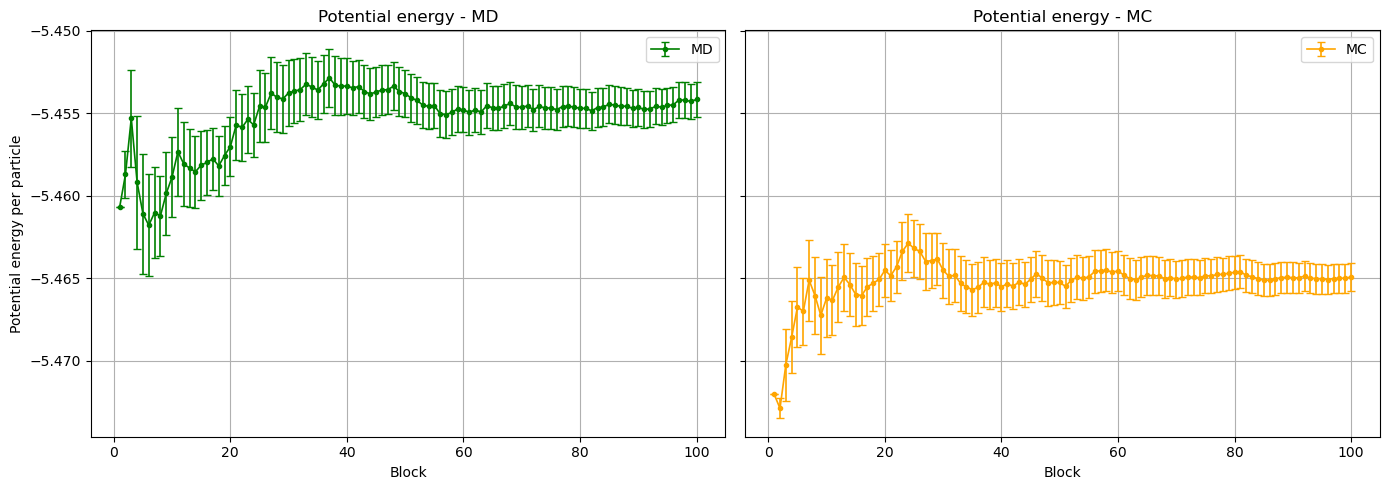

Final MD U/N = -5.45417 +/- 0.00108
Final MC U/N = -5.46493 +/- 0.00086


In [9]:
md_pe = read_block_file("Nsl_simulator_Ex_07_4/MD/potential_energy.dat")
mc_pe = read_block_file("Nsl_simulator_Ex_07_4/MC/potential_energy.dat")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

axes[0].errorbar(
    md_pe["block"],
    md_pe["average"],
    yerr=md_pe["error"],
    fmt="-o",
    markersize=3,
    linewidth=1.2,
    capsize=3,
    color="green",
    label="MD"
)
axes[0].set_xlabel("Block")
axes[0].set_ylabel("Potential energy per particle")
axes[0].set_title("Potential energy - MD")
axes[0].grid(True)
axes[0].legend()

axes[1].errorbar(
    mc_pe["block"],
    mc_pe["average"],
    yerr=mc_pe["error"],
    fmt="-o",
    markersize=3,
    linewidth=1.2,
    capsize=3,
    color="orange",
    label="MC"
)
axes[1].set_xlabel("Block")
axes[1].set_title("Potential energy - MC")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Final MD U/N = {md_pe['average'].iloc[-1]:.5f} +/- {md_pe['error'].iloc[-1]:.5f}")
print(f"Final MC U/N = {mc_pe['average'].iloc[-1]:.5f} +/- {mc_pe['error'].iloc[-1]:.5f}")

#### Comment

The progressive averages of $U/N$ stabilize in both simulations. The final values obtained with the two methods are close, but not identical.

This small difference is probably due to the fact that the equilibrium temperature reached in the MD simulation is not exactly the same as the temperature fixed in the MC simulation. Moreover, the two methods sample different statistical ensembles, so small differences can remain.

### Pressure

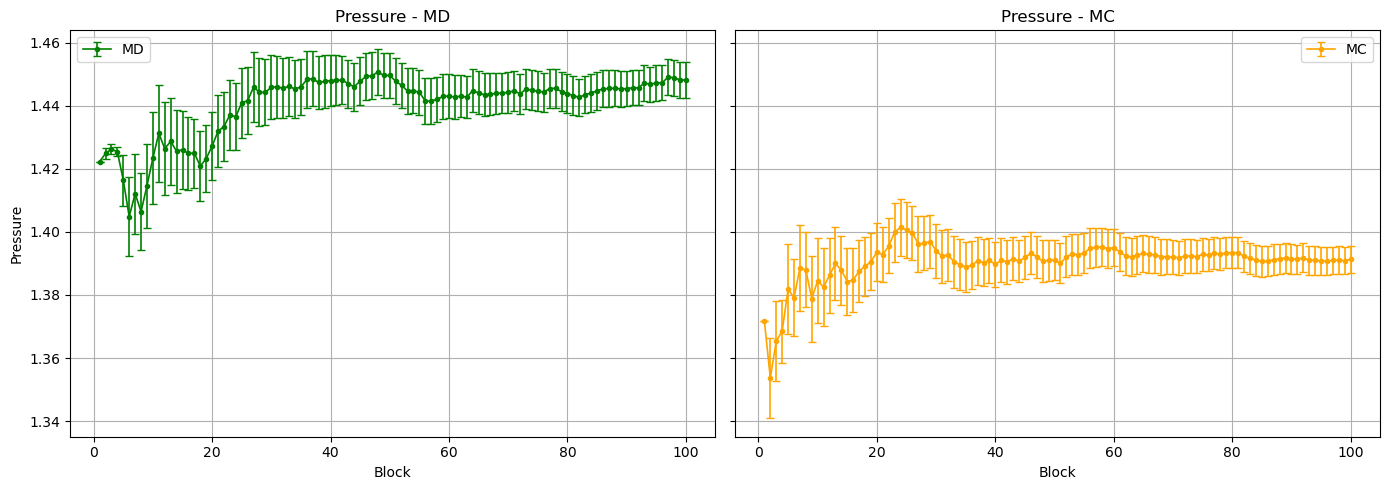

Final MD P = 1.44814 +/- 0.00563 
Final MC P = 1.39129 +/- 0.00428 


In [10]:
md_pr = read_block_file("Nsl_simulator_Ex_07_4/MD/pressure.dat")
mc_pr = read_block_file("Nsl_simulator_Ex_07_4/MC/pressure.dat")

fig, axes = plt.subplots(1, 2, figsize=(14, 5),sharey=True)

axes[0].errorbar(
    md_pr["block"],
    md_pr["average"],
    yerr=md_pr["error"],
    fmt="-o",
    markersize=3,
    linewidth=1.2,
    capsize=3,
    color="green",
    label="MD"
)
axes[0].set_xlabel("Block")
axes[0].set_ylabel("Pressure")
axes[0].set_title("Pressure - MD")
axes[0].grid(True)
axes[0].legend()

axes[1].errorbar(
    mc_pr["block"],
    mc_pr["average"],
    yerr=mc_pr["error"],
    fmt="-o",
    markersize=3,
    linewidth=1.2,
    capsize=3,
    color="orange",
    label="MC"
)
axes[1].set_xlabel("Block")
axes[1].set_title("Pressure - MC")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Final MD P = {md_pr['average'].iloc[-1]:.5f} +/- {md_pr['error'].iloc[-1]:.5f} ")
print(f"Final MC P = {mc_pr['average'].iloc[-1]:.5f} +/- {mc_pr['error'].iloc[-1]:.5f} ")

#### Comment

The pressure estimates obtained with MC and MD are slightly different. This is probably due to the fact that the equilibrium temperature reached in the MD simulation is not exactly the same as the temperature fixed in the MC simulation.

This difference is more visible for the pressure because pressure is computed from the virial term, which depends on the interparticle forces. These forces are very sensitive to the distances between particles, especially in a Lennard-Jones fluid. Therefore, even small differences in the sampled configurations can produce a noticeable difference in the pressure estimate.

### Final comparison

Overall, the MC and MD simulations give similar results for the Lennard-Jones liquid, but the scalar observables $U/N$ and $P$ are slightly different. This is probably related to the fact that the equilibrium temperature is not exactly the same in the two simulations, and to the different statistical ensembles used.

The radial distribution function $g(r)$, instead, agrees very well between the two methods, indicating that the microscopic structure of the liquid is reproduced consistently.